# Graphical results of the benchmarks

Benchmarks for the Contextual Fraction (CF) and the Signalling Fraction (SF) are performed in two scripts `bench_compute_cf.py` and `bench_compute_sf.py` respectively, with two different solvers, Mosek and HiGHS, on two different types of measurements scenarios: n-cycle scenarios and random scenarios. For each of these scenarios, 100 run of the methods were done. We precise these scenarios in their respective subsection.

Practically, the test is done using the python library timeit with a random empirical model, i.e., a random probability distribution. This means that each point on the graph is actually a mean runtime, as some probability distributions might be very fast to compute compared to others.

In [32]:
import json
import matplotlib.pyplot as plt
import numpy as np

## N-cycle scenarios

N-cycle scenarios are scenarios with $N$ measurements, e.g., $X = \{ A_0, \ldots, A_{N-1} \}$ such that the contexts are given by

$$\mathcal{M} = \{ A_0 A_1, A_1 A_2, ..., A_{N-2} A_{N-1}, A_{N-1} A_0 \}$$

and the outcomes are binary $O = \{0, 1\}$.

For each run of the test, we create a random empirical model using the function `numpy.random.random` and normalizing the results.

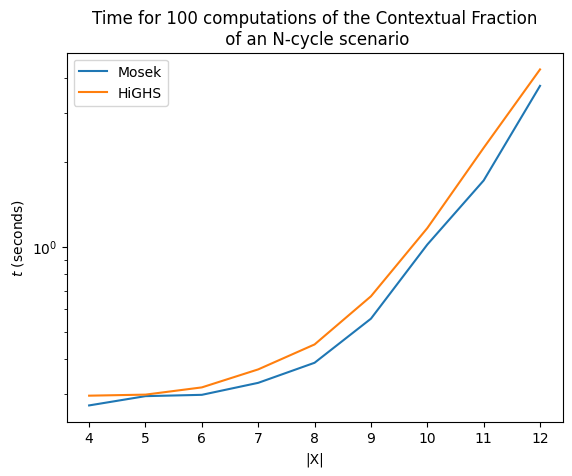

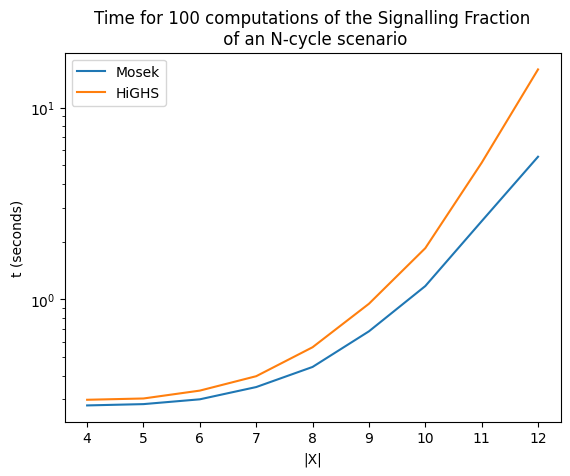

In [33]:
with open("data_cf.json", "r") as f:
    data_cf = json.load(f)

mosek_data_cf = data_cf['n-cycle']['MOSEK']
highs_data_cf = data_cf['n-cycle']['HiGHS']

x_axis_cf = [int(i) for i in mosek_data_cf.keys()]
y_mosek_cf = [float(y) for y in mosek_data_cf.values()]
y_highs_cf = [float(y) for y in highs_data_cf.values()]

plt.plot(x_axis_cf, y_mosek_cf, label='Mosek')
plt.plot(x_axis_cf, y_highs_cf, label='HiGHS')
plt.xlabel(r"|X|")
plt.ylabel(r"$t$ (seconds)")
plt.title("Time for 100 computations of the Contextual Fraction\n of an N-cycle scenario")
# plt.ylim(-0.5,18)
plt.yscale('log')
plt.legend()

plt.show()

with open("data_sf.json", "r") as f:
    data_sf = json.load(f)

mosek_data_sf = data_sf['n-cycle']['MOSEK']
highs_data_sf = data_sf['n-cycle']['HiGHS']

x_axis_sf = [int(i) for i in mosek_data_sf.keys()]
y_mosek_sf = [float(y) for y in mosek_data_sf.values()]
y_highs_sf = [float(y) for y in highs_data_sf.values()]

plt.plot(x_axis_sf, y_mosek_sf, label='Mosek')
plt.plot(x_axis_sf, y_highs_sf, label='HiGHS')
plt.xlabel(r"|X|")
plt.ylabel("t (seconds)")
plt.title("Time for 100 computations of the Signalling Fraction\n of an N-cycle scenario")
plt.legend()
# plt.ylim(-0.5,18)
plt.yscale('log')
plt.show()


## Random scenarios

Here random scenarios refer to scenarios which were generated with pseudo-random contexts, pre-defined number of measurements and fixed outcome set $O= \{0,1\}$.
The contexts are generated in the following way (the code can be found in `bench_compute_cf.py`):
- $X = \{A_0, ..., A_{N-1}\}$
- Randomly pick a context size $K$ between $2$ and $N / 2$ (this ensures large enough contexts to have some overlap)
- Randomly chose a number of contexts $L$ between $2*K$ and $4*K$ (in order to have enough overlap between the contexts and to avoid any trivial scenario).
- Make $L$ iterations, and randomly pick $K$ measurements from $X$, then add them to the set of contexts $\mathcal{M}$.

Once the scenario is built, we generate an empirical model the same way we did for n-cycle scenarios.
A new random measurement scenario is generated at each run, but the time taken during the setup is not taken into account.

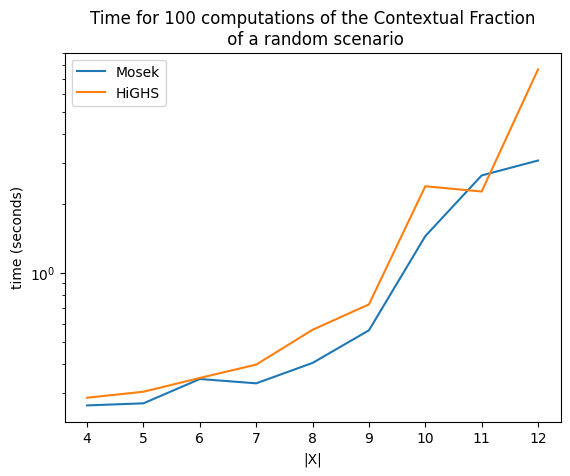

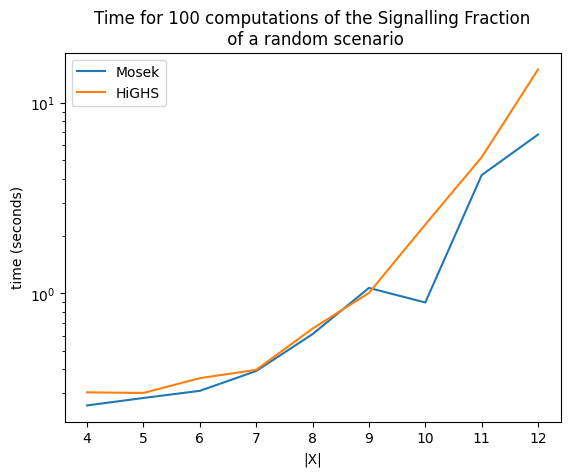

In [34]:
with open("data_cf.json", "r") as f:
    data_cf = json.load(f)

mosek_data_cf = data_cf['random']['MOSEK']
highs_data_cf = data_cf['random']['HiGHS']

x_axis_cf = [int(i) for i in mosek_data_cf.keys()]
y_mosek_cf = [float(y) for y in mosek_data_cf.values()]
y_highs_cf = [float(y) for y in highs_data_cf.values()]

plt.plot(x_axis_cf, y_mosek_cf, label='Mosek')
plt.plot(x_axis_cf, y_highs_cf, label='HiGHS')
plt.xlabel(r"|X|")
plt.ylabel("time (seconds)")
plt.title("Time for 100 computations of the Contextual Fraction\n of a random scenario")
plt.legend()
# plt.ylim(-0.5,18)
plt.yscale('log')
plt.show()

with open("data_sf.json", "r") as f:
    data_sf = json.load(f)

mosek_data_sf = data_sf['random']['MOSEK']
highs_data_sf = data_sf['random']['HiGHS']

x_axis_sf = [int(i) for i in mosek_data_sf.keys()]
y_mosek_sf = [float(y) for y in mosek_data_sf.values()]
y_highs_sf = [float(y) for y in highs_data_sf.values()]

plt.plot(x_axis_sf, y_mosek_sf, label='Mosek')
plt.plot(x_axis_sf, y_highs_sf, label='HiGHS')
plt.xlabel(r"|X|")
plt.ylabel("time (seconds)")
plt.title("Time for 100 computations of the Signalling Fraction\n of a random scenario")
plt.legend()
# plt.ylim(-0.5,18)
plt.yscale('log')
plt.show()
